In [60]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import time
import copy
import gc
import matplotlib.pyplot as plt

In [61]:
data = np.load("physics_data.npy")

print("Dataset shape:", data.shape)
print("Dataset dtype:", data.dtype)

Dataset shape: (1000000, 13)
Dataset dtype: float64


In [62]:
X = data[:, :5]
Y = data[:, 5:13]

target_names = [
    "position",
    "velocity",
    "beta",
    "gamma",
    "momentum",
    "kinetic_energy",
    "total_energy",
    "proper_time",
]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1000000, 5)
Y shape: (1000000, 8)


In [63]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (800000, 5)
Validation: (100000, 5)
Testing: (100000, 5)


In [64]:
X_scaler = StandardScaler()
Y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)

Y_train_scaled = Y_scaler.fit_transform(Y_train)
Y_val_scaled = Y_scaler.transform(Y_val)
Y_test_scaled = Y_scaler.transform(Y_test)

In [65]:
def polynomial_features_degree_2(X):
    features = [X]

    # Squared terms
    features.append(X ** 2)

    # Pairwise multiplication terms
    for i in range(X.shape[1]):
        for j in range(i + 1, X.shape[1]):
            features.append(
                (X[:, i] * X[:, j]).reshape(-1, 1)
            )

    return np.concatenate(features, axis=1)

In [66]:
X_train_poly = polynomial_features_degree_2(
    X_train_scaled
)

X_val_poly = polynomial_features_degree_2(
    X_val_scaled
)

X_test_poly = polynomial_features_degree_2(
    X_test_scaled
)

print("Polynomial feature shape:")
print("Train:", X_train_poly.shape)
print("Val:", X_val_poly.shape)
print("Test:", X_test_poly.shape)

Polynomial feature shape:
Train: (800000, 20)
Val: (100000, 20)
Test: (100000, 20)


In [67]:
X_train_tensor = torch.tensor(
    X_train_poly,
    dtype=torch.float32,
)

Y_train_tensor = torch.tensor(
    Y_train_scaled,
    dtype=torch.float32,
)

X_val_tensor = torch.tensor(
    X_val_poly,
    dtype=torch.float32,
)

Y_val_tensor = torch.tensor(
    Y_val_scaled,
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test_poly,
    dtype=torch.float32,
)

Y_test_tensor = torch.tensor(
    Y_test_scaled,
    dtype=torch.float32,
)

In [68]:
X_train_tensor = torch.tensor(
    X_train_poly,
    dtype=torch.float32,
)

Y_train_tensor = torch.tensor(
    Y_train_scaled,
    dtype=torch.float32,
)

X_val_tensor = torch.tensor(
    X_val_poly,
    dtype=torch.float32,
)

Y_val_tensor = torch.tensor(
    Y_val_scaled,
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test_poly,
    dtype=torch.float32,
)

Y_test_tensor = torch.tensor(
    Y_test_scaled,
    dtype=torch.float32,
)

In [69]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [80]:
batch_size = 524288

train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor,
)

val_dataset = TensorDataset(
    X_val_tensor,
    Y_val_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

print("Batch size:", batch_size)

Batch size: 524288


In [81]:
class PolynomialNeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # 20 polynomial features
            nn.Linear(20, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),

            nn.Linear(32, 28),
            nn.ReLU(),

            nn.Linear(28, 28),
            nn.ReLU(),

            nn.Linear(28, 24),
            nn.ReLU(),

            nn.Linear(24, 24),
            nn.ReLU(),

            # 8 physics outputs
            nn.Linear(24, 8)
        )

    def forward(self, x):
        return self.network(x)


model = PolynomialNeuralNetwork().to(device)

print(model)

PolynomialNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=28, bias=True)
    (7): ReLU()
    (8): Linear(in_features=28, out_features=28, bias=True)
    (9): ReLU()
    (10): Linear(in_features=28, out_features=24, bias=True)
    (11): ReLU()
    (12): Linear(in_features=24, out_features=24, bias=True)
    (13): ReLU()
    (14): Linear(in_features=24, out_features=8, bias=True)
  )
)


In [82]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    total_parameters
)

Trainable parameters: 6016


In [83]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

In [84]:
epochs = 50
patience = 8
batch_size = 524288
best_val_loss = float("inf")
best_model_state = None

epochs_without_improvement = 0

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(epochs):

    # Training
    model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True,
        )

        Y_batch = Y_batch.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            Y_batch,
        )

        loss.backward()

        optimizer.step()

        current_batch_size = X_batch.size(0)

        running_train_loss += (
            loss.item() * current_batch_size
        )

        train_samples += current_batch_size

    train_loss = (
        running_train_loss / train_samples
    )

    # Validation
    model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True,
            )

            Y_batch = Y_batch.to(
                device,
                non_blocking=True,
            )

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                Y_batch,
            )

            current_batch_size = X_batch.size(0)

            running_val_loss += (
                loss.item() * current_batch_size
            )

            val_samples += current_batch_size

    val_loss = (
        running_val_loss / val_samples
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.2e}"
    )

    # Best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}"
        )

        break


training_time = time.time() - start_time

print(
    f"\nTraining time: "
    f"{training_time / 60:.2f} minutes"
)

Epoch 01/50 | Train Loss: 1.021879 | Val Loss: 0.912130 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 1.019199 | Val Loss: 0.909635 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 1.016721 | Val Loss: 0.907229 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 1.014336 | Val Loss: 0.904930 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 1.012053 | Val Loss: 0.902689 | LR: 1.00e-03
Epoch 06/50 | Train Loss: 1.009820 | Val Loss: 0.900449 | LR: 1.00e-03
Epoch 07/50 | Train Loss: 1.007574 | Val Loss: 0.898149 | LR: 1.00e-03
Epoch 08/50 | Train Loss: 1.005258 | Val Loss: 0.895691 | LR: 1.00e-03
Epoch 09/50 | Train Loss: 1.002762 | Val Loss: 0.893004 | LR: 1.00e-03
Epoch 10/50 | Train Loss: 1.000020 | Val Loss: 0.890064 | LR: 1.00e-03
Epoch 11/50 | Train Loss: 0.997047 | Val Loss: 0.886929 | LR: 1.00e-03
Epoch 12/50 | Train Loss: 0.993854 | Val Loss: 0.883425 | LR: 1.00e-03
Epoch 13/50 | Train Loss: 0.990230 | Val Loss: 0.879307 | LR: 1.00e-03
Epoch 14/50 | Train Loss: 0.985942 | Val Loss: 0.874280 | LR: 1.00e-03
Epoch 

In [85]:
model.load_state_dict(best_model_state)

model.eval()

print(
    "Best validation loss:",
    best_val_loss
)

Best validation loss: 0.5662464499473572


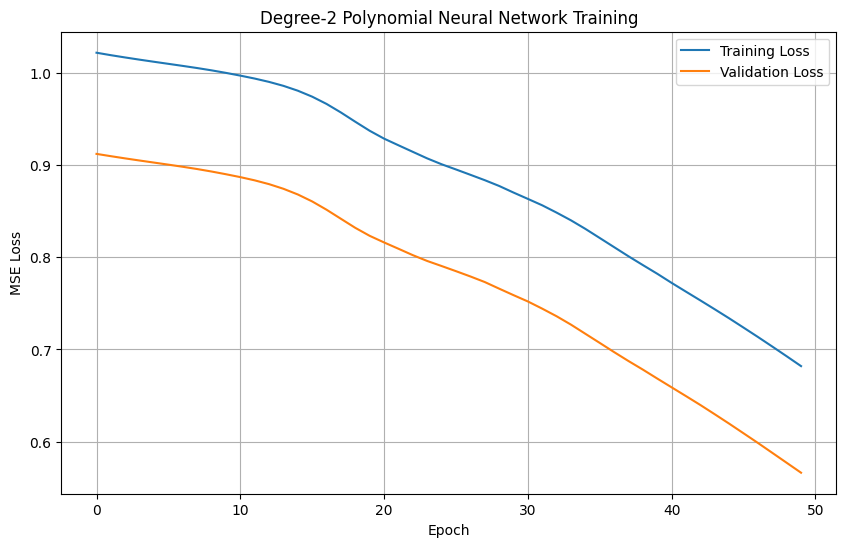

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss",
)

plt.plot(
    val_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Degree-2 Polynomial Neural Network Training"
)

plt.legend()
plt.grid(True)

plt.show()

In [87]:
model.eval()

predictions_scaled = []

with torch.no_grad():

    for i in range(
        0,
        len(X_test_tensor),
        batch_size,
    ):

        X_batch = X_test_tensor[
            i:i + batch_size
        ].to(device)

        prediction = model(X_batch)

        predictions_scaled.append(
            prediction.cpu().numpy()
        )

Y_pred_scaled = np.concatenate(
    predictions_scaled,
    axis=0,
)

Y_pred = Y_scaler.inverse_transform(
    Y_pred_scaled
)

print(
    "Prediction shape:",
    Y_pred.shape
)

Prediction shape: (100000, 8)


In [88]:
results = []

for i, name in enumerate(target_names):

    rmse = np.sqrt(
        mean_squared_error(
            Y_test[:, i],
            Y_pred[:, i],
        )
    )

    mae = mean_absolute_error(
        Y_test[:, i],
        Y_pred[:, i],
    )

    r2 = r2_score(
        Y_test[:, i],
        Y_pred[:, i],
    )

    results.append({
        "Target": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

normal_results = pd.DataFrame(
    results
)

print(
    normal_results.to_string(
        index=False
    )
)

        Target         RMSE          MAE        R2
      position 2.660754e+12 1.083598e+12  0.379777
      velocity 1.005112e+08 5.958040e+07  0.394616
          beta 3.362502e-01 2.048193e-01  0.391068
         gamma 1.331612e+04 3.174707e+03 -0.041733
      momentum 1.385310e+14 3.386752e+13  0.376285
kinetic_energy 4.195853e+22 9.784376e+21  0.230437
  total_energy 4.195157e+22 1.095860e+22  0.408258
   proper_time 6.481064e+03 2.905936e+03  0.584221


In [91]:
extreme_data = np.load(
    "relativistic_extreme_test_10k.npy"
)

print(
    "Extreme dataset shape:",
    extreme_data.shape
)

Extreme dataset shape: (10000, 13)


In [93]:
X_extreme = extreme_data[:, :5]
Y_extreme = extreme_data[:, 5:13]

X_extreme_scaled = X_scaler.transform(X_extreme)

X_extreme_poly = polynomial_features_degree_2(
    X_extreme_scaled
)

X_extreme_tensor = torch.tensor(
    X_extreme_poly,
    dtype=torch.float32,
)

In [94]:
extreme_predictions_scaled = []

with torch.no_grad():

    for i in range(
        0,
        len(X_extreme_tensor),
        batch_size,
    ):

        X_batch = X_extreme_tensor[
            i:i + batch_size
        ].to(device)

        prediction = model(X_batch)

        extreme_predictions_scaled.append(
            prediction.cpu().numpy()
        )

Y_extreme_pred_scaled = np.concatenate(
    extreme_predictions_scaled,
    axis=0,
)

Y_extreme_pred = Y_scaler.inverse_transform(
    Y_extreme_pred_scaled
)

print(
    "Extreme prediction shape:",
    Y_extreme_pred.shape
)

Extreme prediction shape: (10000, 8)


In [95]:
extreme_results = []

for i, name in enumerate(target_names):

    rmse = np.sqrt(
        mean_squared_error(
            Y_extreme[:, i],
            Y_extreme_pred[:, i],
        )
    )

    mae = mean_absolute_error(
        Y_extreme[:, i],
        Y_extreme_pred[:, i],
    )

    r2 = r2_score(
        Y_extreme[:, i],
        Y_extreme_pred[:, i],
    )

    extreme_results.append({
        "Target": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

extreme_results = pd.DataFrame(
    extreme_results
)

print(
    extreme_results.to_string(
        index=False
    )
)

        Target         RMSE          MAE        R2
      position 2.734847e+12 1.073492e+12  0.338885
      velocity 9.611590e+07 5.751458e+07  0.418668
          beta 3.221926e-01 1.986225e-01  0.412908
         gamma 1.804661e+04 3.318972e+03 -0.013725
      momentum 1.302169e+14 3.463639e+13  0.438777
kinetic_energy 3.953063e+22 1.001908e+22  0.281995
  total_energy 3.917078e+22 1.131057e+22  0.476849
   proper_time 6.285576e+03 2.867156e+03  0.574565


In [96]:
normal_predictions_df = pd.DataFrame(
    Y_pred,
    columns=target_names,
)

extreme_predictions_df = pd.DataFrame(
    Y_extreme_pred,
    columns=target_names,
)

normal_predictions_df.to_csv(
    "polynomial_nn_degree2_normal_predictions.csv",
    index=False,
)

extreme_predictions_df.to_csv(
    "polynomial_nn_degree2_extreme_predictions.csv",
    index=False,
)

normal_results.to_csv(
    "polynomial_nn_degree2_normal_metrics.csv",
    index=False,
)

extreme_results.to_csv(
    "polynomial_nn_degree2_extreme_metrics.csv",
    index=False,
)

print("Results saved.")

Results saved.


In [97]:
model_path = "polynomial_neural_network_degree2.pt"

torch.save(
    model.state_dict(),
    model_path,
)

print(
    "Model saved:",
    model_path
)

Model saved: polynomial_neural_network_degree2.pt


In [98]:
from google.colab import files

files.download(
    "polynomial_nn_degree2_normal_metrics.csv"
)

files.download(
    "polynomial_nn_degree2_extreme_metrics.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
files.download(
    "polynomial_neural_network_degree2.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>